# Chapter 3 - Dimensionality Reduction Techniques

Reproduksi pembelajaran **scikit-learn Cookbook, Third Edition**, John Sukup (Packt, 2025), untuk mata kuliah Pembelajaran Mesin.

Kode diadaptasi dari [repo penerbit](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/c624b1279cf23a83273e806cede15cad0c9e5500/Chapter_3) beserta exercise solutions. Teori dan interpretasi disusun dalam bahasa Indonesia. Perubahan penting dijelaskan di README. Dataset sintetis diberi label, output disimpan, dan seluruh notebook dapat dijalankan ulang dari kernel baru.

## Daftar Isi

- [Principal Component Analysis (PCA)](#principal-component-analysis-pca)
- [Linear Discriminant Analysis (LDA)](#linear-discriminant-analysis-lda)
- [t-SNE for Data Visualization](#t-sne-for-data-visualization)
- [Practical Exercises on Dimensionality Reduction](#practical-exercises-on-dimensionality-reduction)
- [Pemeriksaan Hasil](#pemeriksaan-hasil)
- [Ringkasan Bab](#ringkasan-bab)

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.utils import Bunch

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data'
np.random.seed(2024)
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 25)
plt.rcParams.update({'figure.dpi': 100, 'savefig.bbox': 'tight'})

## Principal Component Analysis (PCA)

Dimensionality reduction merangkum fitur berkorelasi untuk mengurangi biaya, noise, dan kesulitan visualisasi. PCA bersifat unsupervised: pada data yang dipusatkan, komponen diperoleh dari eigenvector matriks kovarians atau SVD. Arah pertama memaksimalkan varians; arah berikutnya ortogonal. Explained variance ratio adalah proporsi varians yang dipertahankan, bukan accuracy atau proporsi informasi kelas.

Wine memiliki 178 sampel, 13 fitur dan tiga kelas. Scaling dipakai karena satuan fiturnya berbeda. Dua komponen memberi proyeksi 2D dengan kehilangan informasi; pemisahan warna hanya deskripsi. PCA dua fitur menjadi dua komponen adalah rotasi, bukan pengurangan jumlah dimensi.

In [2]:
# Load libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
import warnings

# Set random seed for reproducibility and suppress warnings
np.random.seed(2024)


#Load dataset
wine = load_wine()
df_wine = pd.DataFrame(data=wine.data, columns=wine.feature_names)
target_wine = wine.target
display(df_wine.head(10))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,...,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,...,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,...,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,...,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,...,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,...,0.39,1.82,4.32,1.04,2.93,735.0
5,14.20,1.76,2.45,15.2,112.0,3.27,...,0.34,1.97,6.75,1.05,2.85,1450.0
6,14.39,1.87,2.45,14.6,96.0,2.50,...,0.30,1.98,5.25,1.02,3.58,1290.0
7,14.06,2.15,2.61,17.6,121.0,2.60,...,0.31,1.25,5.05,1.06,3.58,1295.0
8,14.83,1.64,2.17,14.0,97.0,2.80,...,0.29,1.98,5.20,1.08,2.85,1045.0
9,13.86,1.35,2.27,16.0,98.0,2.98,...,0.22,1.85,7.22,1.01,3.55,1045.0


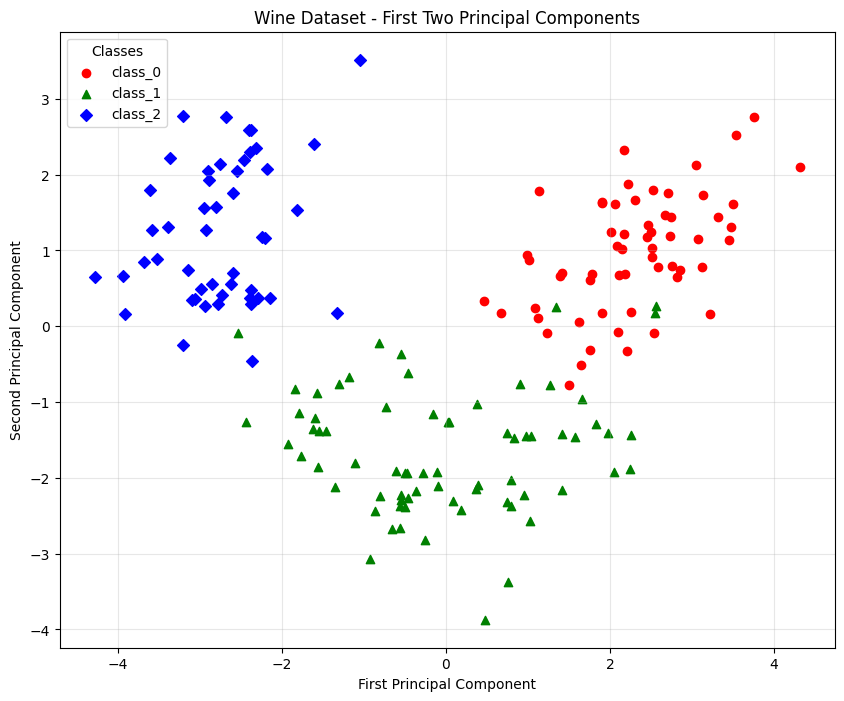

In [3]:
# Load libraries
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Create a pipeline for PCA
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Always scale before PCA
    ('pca', PCA(n_components=2))   # Reduce to 2 dimensions
])

# Fit and transform the data
X_pca = pca_pipeline.fit_transform(df_wine)

# Visualize the transformed data
plt.figure(figsize=(10, 8))
shapes = ['o', '^', 'D']
colors = ['r', 'g', 'b']

# Plot the scatter points
for i, (shape, color) in enumerate(zip(shapes, colors)):
    plt.scatter(X_pca[target_wine == i, 0], X_pca[target_wine == i, 1], 
                c=color, marker=shape, label=wine.target_names[i])

pca = pca_pipeline.named_steps['pca']
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Wine Dataset - First Two Principal Components')
plt.legend(title="Classes")
plt.grid(True, alpha=0.3)
plt.show()

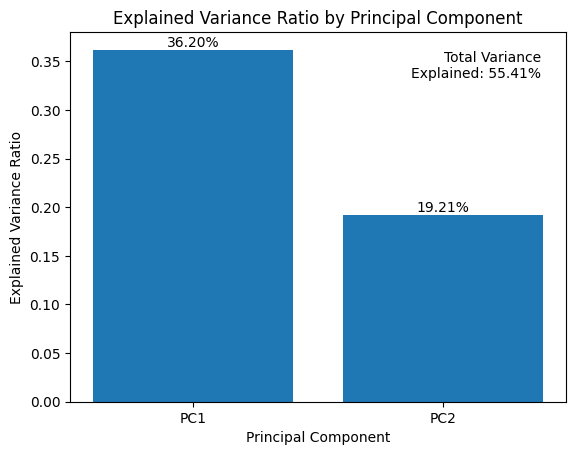

In [4]:
# Get the explained variance ratio
pca = pca_pipeline.named_steps['pca']
explained_variance_ratio = pca.explained_variance_ratio_

# Calculate cumulative variance
cumulative_variance = np.sum(explained_variance_ratio)

# Plot barchart
fig, ax = plt.subplots()

x = np.arange(1, len(explained_variance_ratio) + 1)
y = explained_variance_ratio
bars = ax.bar(x, y)

# Add percentage labels on bars
for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.2%}',
                        ha='center', va='bottom')

# Add cumulative variance text in upper right
ax.text(0.95, 0.95, f'Total Variance\nExplained: {cumulative_variance:.2%}',
                transform=ax.transAxes,
                ha='right', va='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Set custom x-axis labels for the two principal components
ax.set_xticks(x)
ax.set_xticklabels(['PC1', 'PC2'])

ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

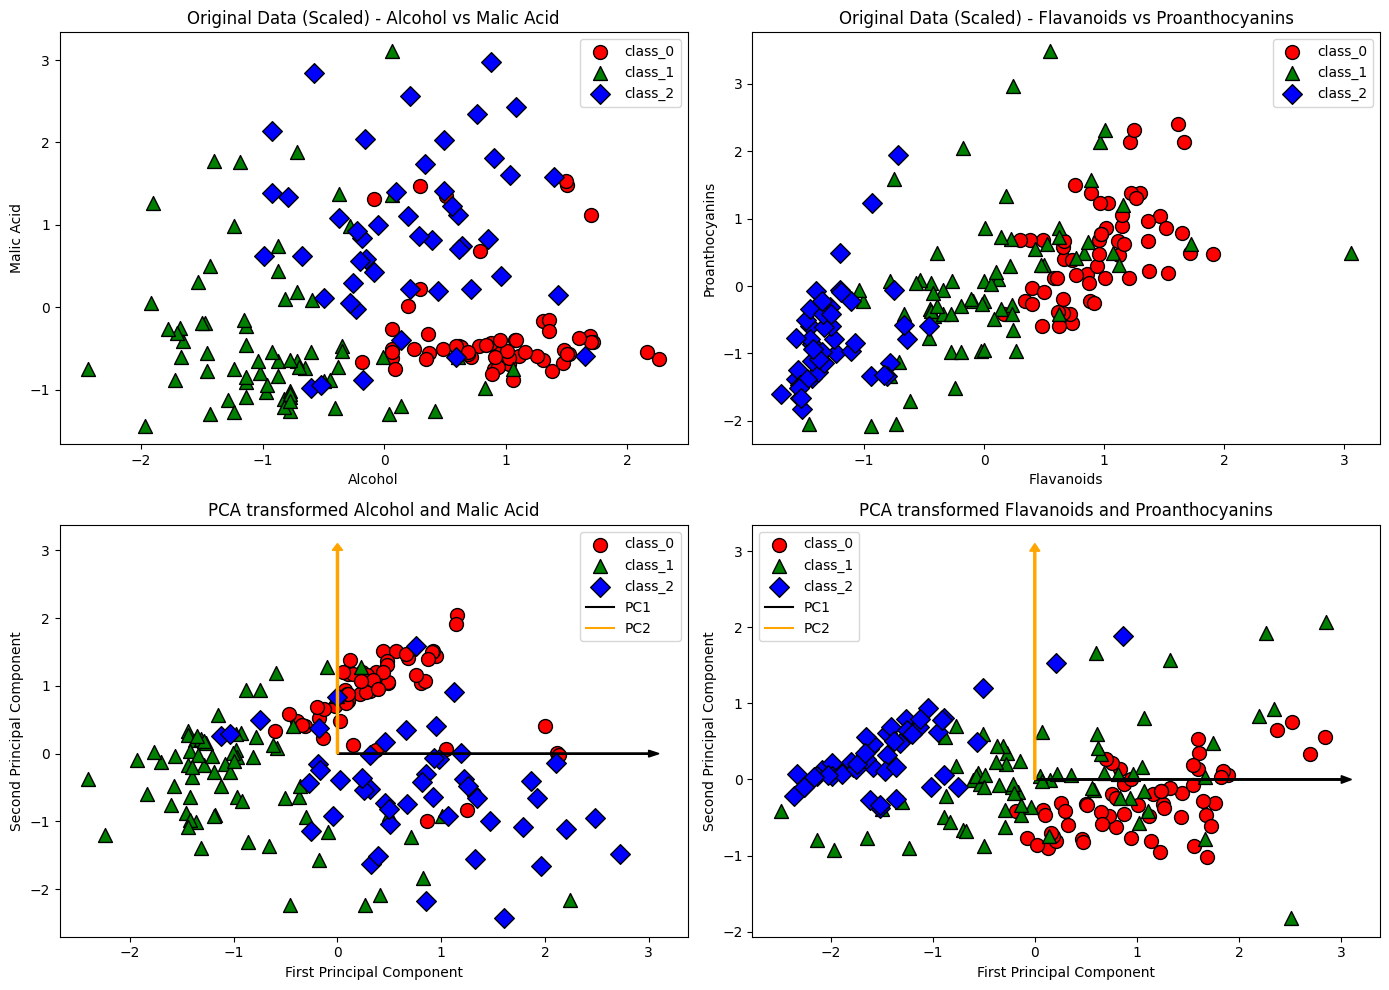

In [5]:
# Choose two features: 'alcohol' and 'malic_acid'
features_1 = ['alcohol', 'malic_acid']
df_wine_subset_1 = df_wine[features_1]
df_wine_subset_1 = pd.DataFrame(StandardScaler().fit_transform(df_wine_subset_1), columns=features_1)

# Perform PCA on the two features
pca_2d_1 = PCA(n_components=2)
X_pca_2d_1 = pca_2d_1.fit_transform(df_wine_subset_1)

# Choose two different features: 'flavanoids' and 'proanthocyanins'
features_2 = ['flavanoids', 'proanthocyanins']
df_wine_subset_2 = df_wine[features_2]
df_wine_subset_2 = pd.DataFrame(StandardScaler().fit_transform(df_wine_subset_2), columns=features_2)

# Perform PCA on the two different features
pca_2d_2 = PCA(n_components=2)
X_pca_2d_2 = pca_2d_2.fit_transform(df_wine_subset_2)

# Create a figure with four subplots in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original data plot 1 (top left)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[0,0].scatter(df_wine_subset_1['alcohol'][mask],
                     df_wine_subset_1['malic_acid'][mask],
                     marker=shape, c=color, edgecolor='k', s=100,
                     label=wine.target_names[i])
axes[0,0].set_xlabel('Alcohol')
axes[0,0].set_ylabel('Malic Acid')
axes[0,0].set_title('Original Data (Scaled) - Alcohol vs Malic Acid')
axes[0,0].legend()

# Original data plot 2 (top right)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[0,1].scatter(df_wine_subset_2['flavanoids'][mask],
                     df_wine_subset_2['proanthocyanins'][mask],
                     marker=shape, c=color, edgecolor='k', s=100,
                     label=wine.target_names[i])
axes[0,1].set_xlabel('Flavanoids')
axes[0,1].set_ylabel('Proanthocyanins')
axes[0,1].set_title('Original Data (Scaled) - Flavanoids vs Proanthocyanins')
axes[0,1].legend()

# PCA plot 1 (bottom left)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[1,0].scatter(X_pca_2d_1[mask, 0], 
                     X_pca_2d_1[mask, 1],
                     marker=shape, c=color, edgecolor='k', s=100,
                     label=wine.target_names[i])
axes[1,0].set_xlabel('First Principal Component')
axes[1,0].set_ylabel('Second Principal Component')
axes[1,0].set_title('PCA transformed Alcohol and Malic Acid')

# Plot the principal components as vectors for the first PCA plot
origin_1 = np.zeros(2)
components_1 = np.eye(2)
arrow_colors_1 = ['black', 'orange']
scaling = 3
for i, component in enumerate(components_1):
    axes[1,0].arrow(origin_1[0], origin_1[1], component[0] * scaling, component[1] * scaling,
                    color=arrow_colors_1[i], width=0.02, head_width=0.1, head_length=0.1)
    axes[1,0].plot([], [], color=arrow_colors_1[i], label=f'PC{i+1}')

axes[1,0].legend()

# PCA plot 2 (bottom right)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[1,1].scatter(X_pca_2d_2[mask, 0],
                     X_pca_2d_2[mask, 1],
                     marker=shape, c=color, edgecolor='k', s=100,
                     label=wine.target_names[i])
axes[1,1].set_xlabel('First Principal Component')
axes[1,1].set_ylabel('Second Principal Component')
axes[1,1].set_title('PCA transformed Flavanoids and Proanthocyanins')

# Plot the principal components as vectors for the second PCA plot
origin_2 = np.zeros(2)
components_2 = np.eye(2)
for i, component in enumerate(components_2):
    axes[1,1].arrow(origin_2[0], origin_2[1], component[0] * scaling, component[1] * scaling,
                    color=arrow_colors_1[i], width=0.02, head_width=0.1, head_length=0.1)
    axes[1,1].plot([], [], color=arrow_colors_1[i], label=f'PC{i+1}')

axes[1,1].legend()

plt.tight_layout()
plt.show()

## Linear Discriminant Analysis (LDA)

LDA supervised mencari proyeksi dengan sebaran antarkelas besar relatif terhadap sebaran dalam kelas, berdasarkan rasio $w^T S_B w/(w^T S_W w)$. Jumlah komponen maksimal $\min(p,K-1)$; Wine dengan tiga kelas mempunyai paling banyak dua komponen. Sebagai classifier, LDA memakai asumsi distribusi normal kelas dengan kovarians bersama.

PCA tidak menggunakan label dan menjaga varians, sedangkan LDA memakai label untuk separabilitas. Karena label dipakai saat fit, visualisasi LDA pada seluruh data bukan evaluasi klasifikasi di luar sampel.

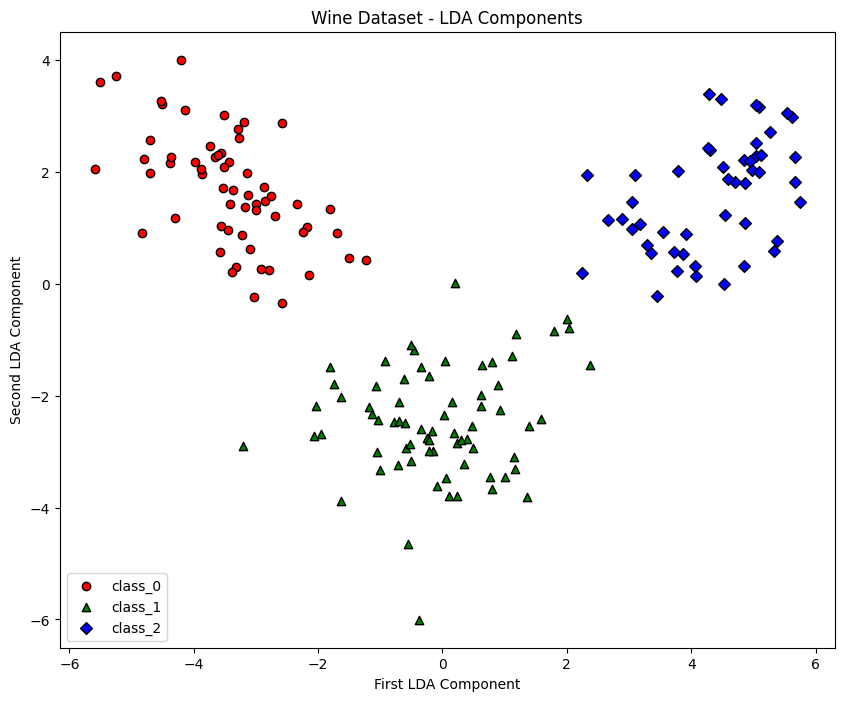

In [6]:
# Load libraries
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Split wine dataset by features and target
X_wine, y_wine = wine.data, wine.target

# Create LDA pipeline for wine dataset
lda_pipeline_wine = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components=2))  # min(n_features, n_classes - 1) for wine dataset is 2
])

# Fit and transform the wine data
X_lda_wine = lda_pipeline_wine.fit_transform(X_wine, y_wine)

# Visualize LDA transformation for wine dataset
plt.figure(figsize=(10, 8))

# Define markers and colors for each class
shapes = ['o', '^', 'D']
colors = ['r', 'g', 'b']

# Plot each class with different marker and color
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(X_lda_wine[mask, 0], X_lda_wine[mask, 1],
               c=color, marker=shape, edgecolor='black',
               label=wine.target_names[i])

plt.xlabel('First LDA Component')
plt.ylabel('Second LDA Component')
plt.title('Wine Dataset - LDA Components')
plt.legend()
plt.show()

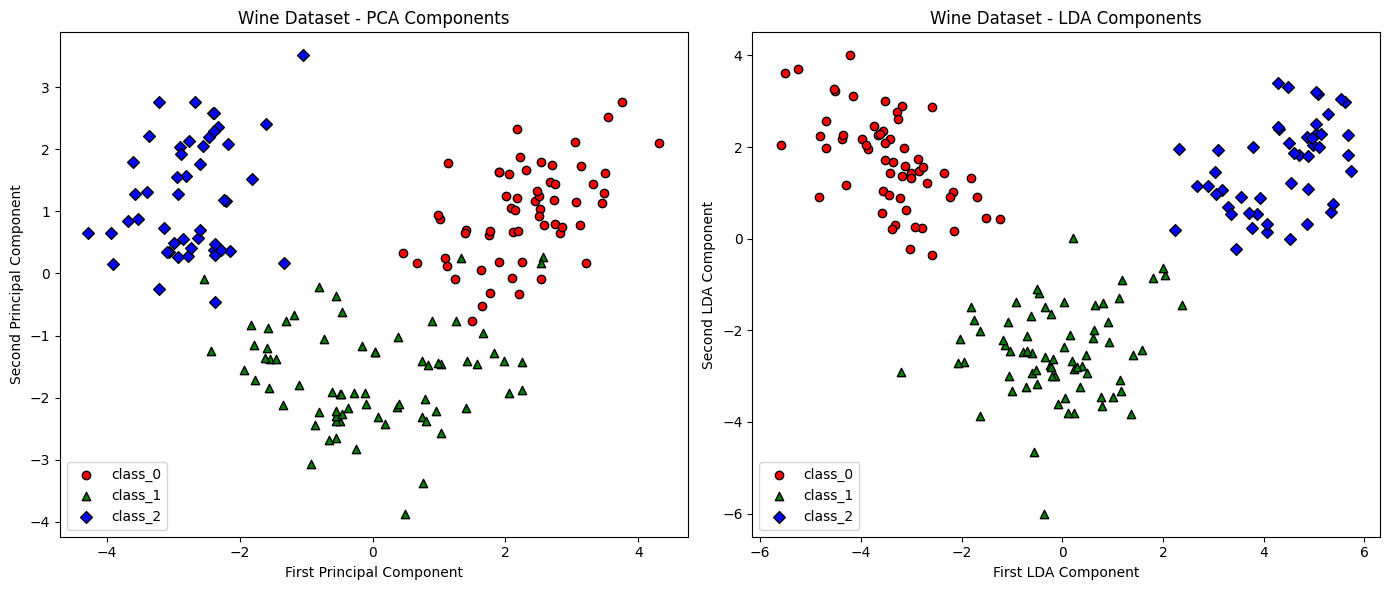

In [7]:
# Create side-by-side plots
plt.figure(figsize=(14, 6))

plt.subplot(121)
shapes = ['o', '^', 'D'] 
colors = ['r', 'g', 'b']

for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, marker=shape, edgecolor='black',
               label=wine.target_names[i])

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Wine Dataset - PCA Components')
plt.legend()

plt.subplot(122)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(X_lda_wine[mask, 0], X_lda_wine[mask, 1],
               c=color, marker=shape, edgecolor='black',
               label=wine.target_names[i])

plt.xlabel('First LDA Component')
plt.ylabel('Second LDA Component')
plt.title('Wine Dataset - LDA Components')
plt.legend()

plt.tight_layout()
plt.show()

## t-SNE for Data Visualization

t-SNE memetakan probabilitas kedekatan antarpengamatan dari dimensi tinggi ke 2D dengan meminimalkan KL divergence. Distribusi Student-t pada ruang rendah membantu mengurangi crowding. Perplexity mengatur skala tetangga efektif, bukan jumlah cluster; learning rate, initialization, dan seed juga memengaruhi bentuk.

Digits mempunyai 1.797 gambar 8×8 yang direpresentasikan oleh 64 intensitas piksel. Kedekatan lokal pada plot berguna untuk eksplorasi, tetapi ukuran dan jarak antarcluster tidak harus mencerminkan ruang asli. t-SNE scikit-learn tidak menyediakan `transform` untuk titik baru, sehingga tidak digunakan sebagai preprocessing biasa untuk test set.

In [8]:
# Load libraries
from sklearn.datasets import load_digits

# Load dataset
digits = load_digits()

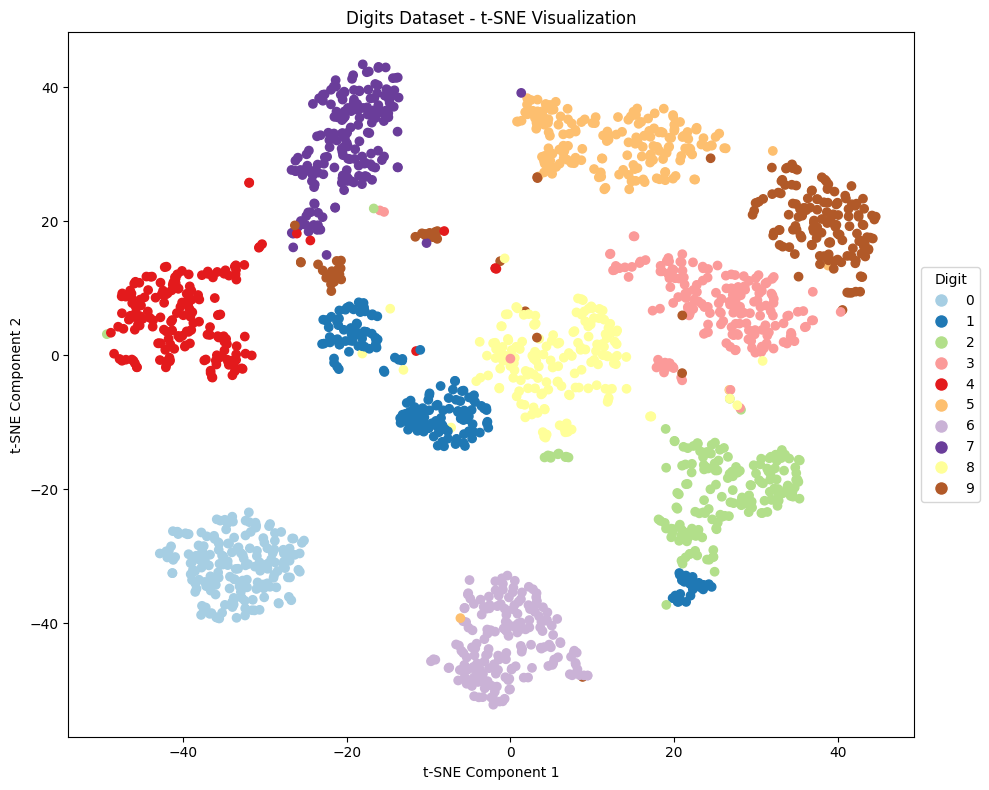

In [9]:
# Load libraries
from sklearn.manifold import TSNE

# Create t-SNE pipeline
tsne_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('tsne', TSNE(n_components=2, random_state=2024))
])

# Fit and transform the digits data
X_tsne = tsne_pipeline.fit_transform(digits.data)
# Visualize t-SNE results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=digits.target, cmap='Paired', label=digits.target)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Digits Dataset - t-SNE Visualization')

# Create legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                             markerfacecolor=plt.cm.Paired(i/9), 
                             label=str(i), markersize=10)
                  for i in range(10)]
plt.legend(handles=legend_elements, title='Digit', loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

## Practical Exercises on Dimensionality Reduction

Latihan pertama membandingkan pipeline StandardScaler–LogisticRegression dengan pipeline yang menambahkan PCA dan mempertahankan 95% varians. Keduanya belajar hanya pada training. Berkurangnya fitur dapat mempercepat model, tetapi varians tinggi belum tentu paling informatif untuk target.

Latihan kedua membandingkan warna label digit dengan hasil KMeans pada proyeksi t-SNE yang sama. Nomor cluster tidak identik dengan nomor digit dan tidak boleh dibandingkan sebagai label classifier tanpa pemetaan. PCA cocok untuk kompresi linear dan transform data baru; LDA cocok ketika label tersedia; t-SNE cocok untuk eksplorasi lokal. Pemilihan perlu mempertimbangkan tujuan, biaya, stabilitas, dan skor validation.

### Latihan 1: PCA with Logistic Regression

Pipeline LogisticRegression dibandingkan dengan dan tanpa PCA pada Digits. Scaling dan PCA dipelajari hanya dari training; accuracy dihitung pada test yang sama.

In [10]:
# Load libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=2024
)

# Pipeline without PCA
pipeline_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

# Pipeline with PCA
pipeline_with_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),  # Keep 95% of variance
    ('clf', LogisticRegression(max_iter=1000))
])

# Fit and evaluate both pipelines
pipeline_no_pca.fit(X_train, y_train)
pipeline_with_pca.fit(X_train, y_train)

# Print results
print("Accuracy without PCA:", 
      accuracy_score(y_test, pipeline_no_pca.predict(X_test)))
print("Accuracy with PCA:", 
      accuracy_score(y_test, pipeline_with_pca.predict(X_test)))

digits_accuracy_no_pca = accuracy_score(y_test, pipeline_no_pca.predict(X_test))
digits_accuracy_pca = accuracy_score(y_test, pipeline_with_pca.predict(X_test))
digits_pca_components = pipeline_with_pca.named_steps['pca'].n_components_

Accuracy without PCA: 0.975
Accuracy with PCA: 0.9638888888888889


### Latihan 2: t-SNE for Clustering Visualization

KMeans dilatih pada fitur Digits dan hasil cluster diberi warna pada proyeksi t-SNE yang sudah dibuat. Label cluster tidak dianggap identik dengan nomor digit.

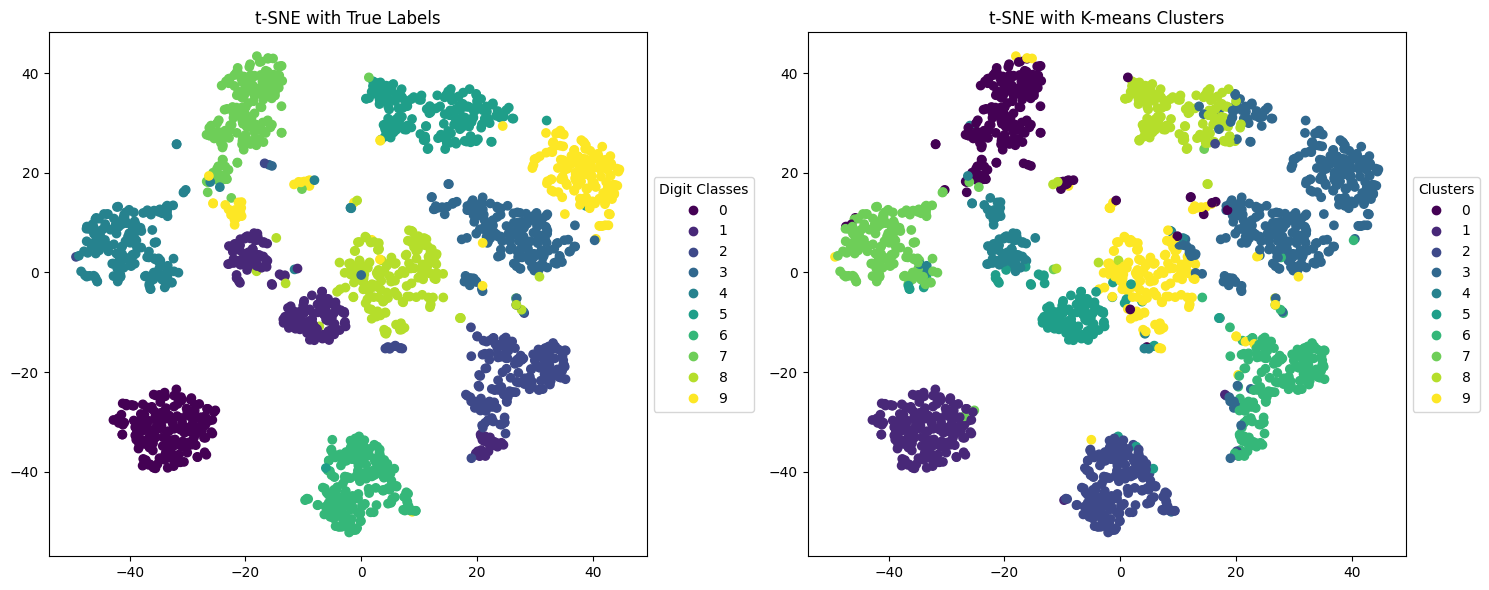

In [11]:
# Load libraries
from sklearn.cluster import KMeans

# Apply K-means clustering
kmeans = KMeans(n_clusters=10, random_state=2024)
cluster_labels = kmeans.fit_predict(digits.data)

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot using true labels
scatter1 = ax1.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                      c=digits.target, cmap='viridis')
ax1.set_title('t-SNE with True Labels')
legend1 = ax1.legend(*scatter1.legend_elements(),
                    title="Digit Classes",
                    loc="center left",
                    bbox_to_anchor=(1, 0.5))

# Plot using cluster labels
scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                      c=cluster_labels, cmap='viridis')
ax2.set_title('t-SNE with K-means Clusters')
legend2 = ax2.legend(*scatter2.legend_elements(),
                    title="Clusters",
                    loc="center left", 
                    bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

## Pemeriksaan Hasil

Angka berikut merangkum hasil eksekusi, disertai assertion untuk memeriksa konsistensi tertentu. Pemeriksaan kode tidak membuktikan asumsi statistik atau representativitas data.

In [12]:
chapter_results = {'wine_pca_variance_2d': float(cumulative_variance),
 'digits_test_accuracy_no_pca': float(digits_accuracy_no_pca),
 'digits_test_accuracy_pca': float(digits_accuracy_pca),
 'digits_pca_components': int(digits_pca_components)}
assert X_pca.shape == (178, 2) and X_lda_wine.shape == (178, 2)
assert X_tsne.shape == (1797, 2)
assert 0 <= cumulative_variance <= 1
print(json.dumps(chapter_results, indent=2))

{
  "wine_pca_variance_2d": 0.5540633835693526,
  "digits_test_accuracy_no_pca": 0.975,
  "digits_test_accuracy_pca": 0.9638888888888889,
  "digits_pca_components": 39
}


## Ringkasan Bab

Dua komponen PCA Wine mempertahankan **55.41% varians** setelah scaling. Dua komponen tidak menyimpan seluruh variasi 13 fitur, dan explained variance bukan accuracy klasifikasi. LDA menggunakan label untuk memisahkan kelas; plot seluruh data tidak memberikan skor generalisasi. t-SNE membantu melihat tetangga lokal Digits, tetapi jarak antarpulau dan ukuran cluster tidak ditafsirkan sebagai ukuran pada ruang piksel asli.

Pada latihan Digits, pipeline tanpa PCA menghasilkan **accuracy test 97.50%**, sedangkan pipeline PCA 95% varians menggunakan **39 komponen** dan menghasilkan **96.39%**. Pengurangan dimensi pada split ini mengurangi fitur sekaligus sedikit menurunkan accuracy. Hasil ini memperlihatkan trade-off; PCA tidak otomatis memperbaiki classifier. Warna cluster KMeans pada plot t-SNE merupakan eksplorasi, bukan prediksi nomor digit secara langsung.